In [ ]:
import os
import pydicom
from pydicom.errors import InvalidDicomError
import pandas as pd
import cv2
import numpy as np
import matplotlib.pyplot as plt

class ProcesadorDICOM:
    """
    Clase encargada de simular el comportamiento de un PACS (como dcm4chee),
    gestionando la carga, extracción de metadatos y preparación de imágenes médicas.
    """
    def __init__(self, ruta_directorio: str):
        self.ruta_directorio = ruta_directorio
        self.estudios_cargados = [] # Lista para almacenar los datasets válidos
        self.archivos_invalidos = [] # Registro de logs de errores
        
    def cargar_archivos_dicom(self):
        """
        Escanea el directorio e identifica archivos DICOM válidos utilizando pydicom.dcmread().
        Maneja excepciones de archivos no válidos o corruptos de forma organizada.
        """
        if not os.path.exists(self.ruta_directorio):
            print(f"Error: El directorio '{self.ruta_directorio}' no existe.")
            return []
        
        print(f"Iniciando escaneo en: {self.ruta_directorio}")
        print("--------------------------------------------------")
        
        for nombre_archivo in os.listdir(self.ruta_directorio):
            ruta_completa = os.path.join(self.ruta_directorio, nombre_archivo)
            
            # Omitir si es una carpeta interna
            if os.path.isdir(ruta_completa):
                continue
                
            try:
                # Intentamos leer el archivo con pydicom
                dataset = pydicom.dcmread(ruta_completa)
                self.estudios_cargados.append(dataset)
                
            except InvalidDicomError:
                # Captura si el archivo no tiene la cabecera 'DICM'
                self.archivos_invalidos.append({
                    "archivo": nombre_archivo, 
                    "motivo": "No es un archivo DICOM válido."
                })
            except Exception as e:
                # Captura cualquier otro error físico (archivo bloqueado, corrupto, etc.)
                self.archivos_invalidos.append({
                    "archivo": nombre_archivo, 
                    "motivo": f"Error de lectura: {str(e)}"
                })
                
        print(f" Carga completada.")
        print(f" - Archivos DICOM válidos detectados: {len(self.estudios_cargados)}")
        print(f" - Archivos descartados/erróneos: {len(self.archivos_invalidos)}")
        print("--------------------------------------------------")
        return self.estudios_cargados
    

    def extraer_metadatos(self):
        """
        Punto 4.2: Recorre los archivos cargados, extrae los tags requeridos
        y maneja de forma segura los metadatos faltantes o anonimizados.
        """
        if not self.estudios_cargados:
            print("No hay archivos DICOM cargados para extraer metadatos.")
            return pd.DataFrame()
            
        lista_registros = []
        
        for idx, dataset in enumerate(self.estudios_cargados):
            try:
                # Accedemos a la matriz cruda de píxeles
                matriz_pixeles = dataset.pixel_array
                
                # Calculamos el promedio global de la imagen usando np.mean()
                # Redondeamos a 2 decimales para que la tabla quede limpia y legible
                intensidad_promedio = float(np.mean(matriz_pixeles))
                intensidad_promedio = round(intensidad_promedio, 2)
                
            except AttributeError:
                # Por si algún archivo DICOM de la carpeta es solo metadata y no tiene imagen
                intensidad_promedio = 0.0
            except Exception as e:
                print(f"Error al analizar píxeles del corte {idx}: {str(e)}")
                intensidad_promedio = 0.0




            # Usamos dataset.get('Atributo', 'Valor_Por_Defecto') para evitar caídas por anonimización
            registro = {
                "ID_Paciente": dataset.get("PatientID", "ANÓNIMO"),
                "Nombre_Paciente": str(dataset.get("PatientName", "ANÓNIMO")),
                "UID_Estudio": dataset.get("StudyInstanceUID", "No disponible"),
                "Descripcion_Estudio": dataset.get("StudyDescription", "Sin descripción"),
                "Fecha_Estudio": dataset.get("StudyDate", "00000000"),
                "Modalidad": dataset.get("Modality", "Desconocida"),
                "Filas": dataset.get("Rows", 0),
                "Columnas": dataset.get("Columns", 0),
                "IntensidadPromedio": intensidad_promedio, # <--- Nueva columna requerida
                "Nombre_Archivo_Origen": os.path.basename(dataset.filename) if dataset.filename else f"Corte_{idx}"
            }
            lista_registros.append(registro)
            
        # Convertimos la lista de diccionarios en un DataFrame estructurado
        self.df_metadatos = pd.DataFrame(lista_registros)
        
        print(" Extraction de metadatos completada con éxito.")
        print(f"Campos validados y protegidos contra anonimización: {self.df_metadatos.shape[0]} registros.")
        print("--------------------------------------------------")
        return self.df_metadatos
    
    def exportar_a_csv(self, ruta_salida: str):
        """
        Método complementario de Bioingeniería para persistir la información 
        de la base de datos simulada en un archivo físico.
        """
        if self.df_metadatos.empty:
            print("No hay datos para exportar. Genere el DataFrame primero.")
            return
        
        self.df_metadatos.to_csv(ruta_salida, index=False, encoding='utf-8')
        print(f"Base de datos PACS exportada con éxito en: {ruta_salida}")

    def procesar_imagenes_opencv(self, carpeta_salida: str, umbral_low: int = 30, umbral_high: int = 150):
        """
        [Punto 4.5] Realiza el pipeline de procesamiento de imágenes médicas:
        Normalización, Ecualización de histograma, Detección de bordes (Canny) y Guardado.
        Maneja excepciones para archivos DICOM sin datos de píxeles (SR, PR, etc.).
        """
        if not self.estudios_cargados:
            print("Error: No hay datos DICOM disponibles para procesar imágenes.")
            return

        # Crear el directorio de salida si no existe
        if not os.path.exists(carpeta_salida):
            os.makedirs(carpeta_salida)

        print(f"Iniciando procesamiento con OpenCV en: {carpeta_salida}")
        print(f"Configuración de Canny -> Umbral Bajo: {umbral_low}, Umbral Alto: {umbral_high}")
        print("--------------------------------------------------")

        conteo_procesados = 0

        for idx, dataset in enumerate(self.estudios_cargados):
            try:
                # --- CONTROL DE EXCEPCIONES: FILTRADO DE NO-IMAGEN ---
                # Si el archivo no tiene pixel_array, lanzará un AttributeError
                img_cruda = dataset.pixel_array

                # Obtener nombre base del archivo para el guardado
                nombre_base = os.path.basename(dataset.filename) if dataset.filename else f"corte_{idx}.dcm"
                nombre_puro = os.path.splitext(nombre_base)[0] # Quita el '.dcm'

                # 1. NORMALIZACIÓN (Escalar de 12/16 bits a 8 bits [0, 255])
                img_8bits = cv2.normalize(
                    img_cruda, 
                    None, 
                    alpha=0, 
                    beta=255, 
                    norm_type=cv2.NORM_MINMAX
                ).astype(np.uint8)

                # 2. ECUALIZACIÓN DEL HISTOGRAMA
                img_ecualizada = cv2.equalizeHist(img_8bits)

                # 3. DETECCIÓN DE BORDES DE CANNY
                # Justificación biomédica de umbrales: 
                # El umbral bajo (30) permite capturar estructuras suaves (tejido blando/pulmón).
                # El umbral alto (150) se asegura de amarrar bordes de alto contraste (hueso/aire).
                img_bordes = cv2.Canny(img_ecualizada, umbral_low, umbral_high)

                # 4. GUARDADO DE RESULTADOS (.png)
                ruta_ecualizada = os.path.join(carpeta_salida, f"{nombre_puro}_ecualizada.png")
                ruta_bordes = os.path.join(carpeta_salida, f"{nombre_puro}_bordes.png")

                cv2.imwrite(ruta_ecualizada, img_ecualizada)
                cv2.imwrite(ruta_bordes, img_bordes)

                conteo_procesados += 1

            except AttributeError:
                # Captura archivos sin píxeles (SR, PR, etc.) de forma segura
                print(f" -> Saltando archivo indexado [{idx}]: Modalidad No-Imagen detectada (SR/PR/Captura secundaria).")
            except Exception as e:
                print(f" -> Error inesperado en el corte {idx}: {str(e)}")

        print("--------------------------------------------------")
        print(f" Procesamiento OpenCV finalizado.")
        print(f"Se generaron y guardaron {conteo_procesados * 2} imágenes (.png) en la caché.")
        print("--------------------------------------------------")


    
def generar_reporte_grafico(pacs_objeto, df_datos, indice_corte=49):
    """
    Genera un reporte visual de control de calidad protegiendo 
    todas las variables dentro del bloque try-except.
    """
    import matplotlib.pyplot as plt
    import cv2
    import numpy as np
    
    try:
        # 1. VERIFICACIÓN DE SEGURIDAD DE DATOS
        if not pacs_objeto.estudios_cargados:
            print("Error: No hay estudios cargados en el objeto PACS.")
            return
            
        if indice_corte >= len(pacs_objeto.estudios_cargados):
            print(f"Error: El índice {indice_corte} excede el número de cortes disponibles ({len(pacs_objeto.estudios_cargados)}).")
            return

        # 2. EXTRAER DATASET Y PROCESAR CON OPENCV
        dataset = pacs_objeto.estudios_cargados[indice_corte]
        img_cruda = dataset.pixel_array
        
        # Pipeline de OpenCV
        img_8bits = cv2.normalize(img_cruda, None, alpha=0, beta=255, norm_type=cv2.NORM_MINMAX).astype(np.uint8)
        img_ecualizada = cv2.equalizeHist(img_8bits)
        img_bordes = cv2.Canny(img_ecualizada, 30, 150)
        
        # 3. CONFIGURAR LA FIGURA DE MATPLOTLIB (Ahora dentro del try)
        fig = plt.figure(figsize=(14, 10))
        grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)
        
        # --- FILA 1: PIPELINE DE IMAGEN ---
        ax0 = fig.add_subplot(grid[0, 0])
        ax0.imshow(img_8bits, cmap='gray')
        ax0.set_title(f"1. Original Normalizada\n(Corte {indice_corte})")
        ax0.axis('off')
        
        ax1 = fig.add_subplot(grid[0, 1])
        ax1.imshow(img_ecualizada, cmap='gray')
        ax1.set_title("2. Histograma Ecualizado\n(Resalta tejidos blandos)")
        ax1.axis('off')
        
        ax2 = fig.add_subplot(grid[0, 2])
        ax2.imshow(img_bordes, cmap='gray')
        ax2.set_title("3. Detección de Bordes (Canny)\n(Líneas anatómicas)")
        ax2.axis('off')
        
        # --- FILA 2: GRÁFICO CLÍNICO DE ANÁLISIS DE DATOS ---
        # Buscamos dinámicamente el nombre de la columna para evitar desajustes
        col_archivo = 'Nombre_Archivo_Origen' if 'Nombre_Archivo_Origen' in df_datos.columns else 'Archivo_Origen'
        df_ordenado = df_datos.sort_values(by=col_archivo).reset_index()
        
        ax_grafico = fig.add_subplot(grid[1, :]) 
        ax_grafico.plot(df_ordenado.index, df_ordenado['IntensidadPromedio'], color='teal', linewidth=2.5, label='Intensidad Media')
        ax_grafico.fill_between(df_ordenado.index, df_ordenado['IntensidadPromedio'], color='teal', alpha=0.15)
        
        # Marcar la posición del corte actual en la gráfica
        ax_grafico.axvline(x=indice_corte, color='red', linestyle='--', alpha=0.7, label=f'Posición Corte {indice_corte}')
        
        ax_grafico.set_title("Perfil de Intensidad Promedio a lo largo del Volumen Tomográfico", fontsize=12, fontweight='bold')
        ax_grafico.set_xlabel("Número de Corte Axial (Progreso Z -> Céfalo-Caudal)", fontsize=10)
        ax_grafico.set_ylabel("Intensidad Promedio (Unidades Digitales)", fontsize=10)
        ax_grafico.grid(True, linestyle=':', alpha=0.6)
        ax_grafico.legend(loc='upper right')
        
        # Identificar dinámicamente la columna del ID del Paciente
        col_id = 'ID_Paciente' if 'ID_Paciente' in df_datos.columns else 'Identificador_Paciente'
        plt.suptitle(f"Simulador PACS - Reporte de Control de Calidad\nPaciente: {df_datos[col_id].iloc[0]} | Estudio: {df_datos['Modalidad'].iloc[0]}", 
                     fontsize=14, fontweight='bold', y=0.98)
        
        plt.show()

    except Exception as e:
        print(f"[-] Error crítico al generar el reporte gráfico: {str(e)}")

Iniciando escaneo en: C:/Users/Usuario/Downloads/Datos/Datos/
--------------------------------------------------
 Carga completada.
 - Archivos DICOM válidos detectados: 99
 - Archivos descartados/erróneos: 1
--------------------------------------------------
 Extraction de metadatos completada con éxito.
Campos validados y protegidos contra anonimización: 99 registros.
--------------------------------------------------
Base de datos PACS exportada con éxito en: C:/Users/Usuario/Downloads/Datos/metadatos_pacs.csv
Iniciando procesamiento con OpenCV en: C:/Users/Usuario/Downloads/Datos/Resultados_OpenCV/
Configuración de Canny -> Umbral Bajo: 30, Umbral Alto: 150
--------------------------------------------------
--------------------------------------------------
 Procesamiento OpenCV finalizado.
Se generaron y guardaron 198 imágenes (.png) en la caché.
--------------------------------------------------

=== RESUMEN DE CONTROL DE CALIDAD DEL TALLER ===
  ID_Paciente Modalidad  Intensidad

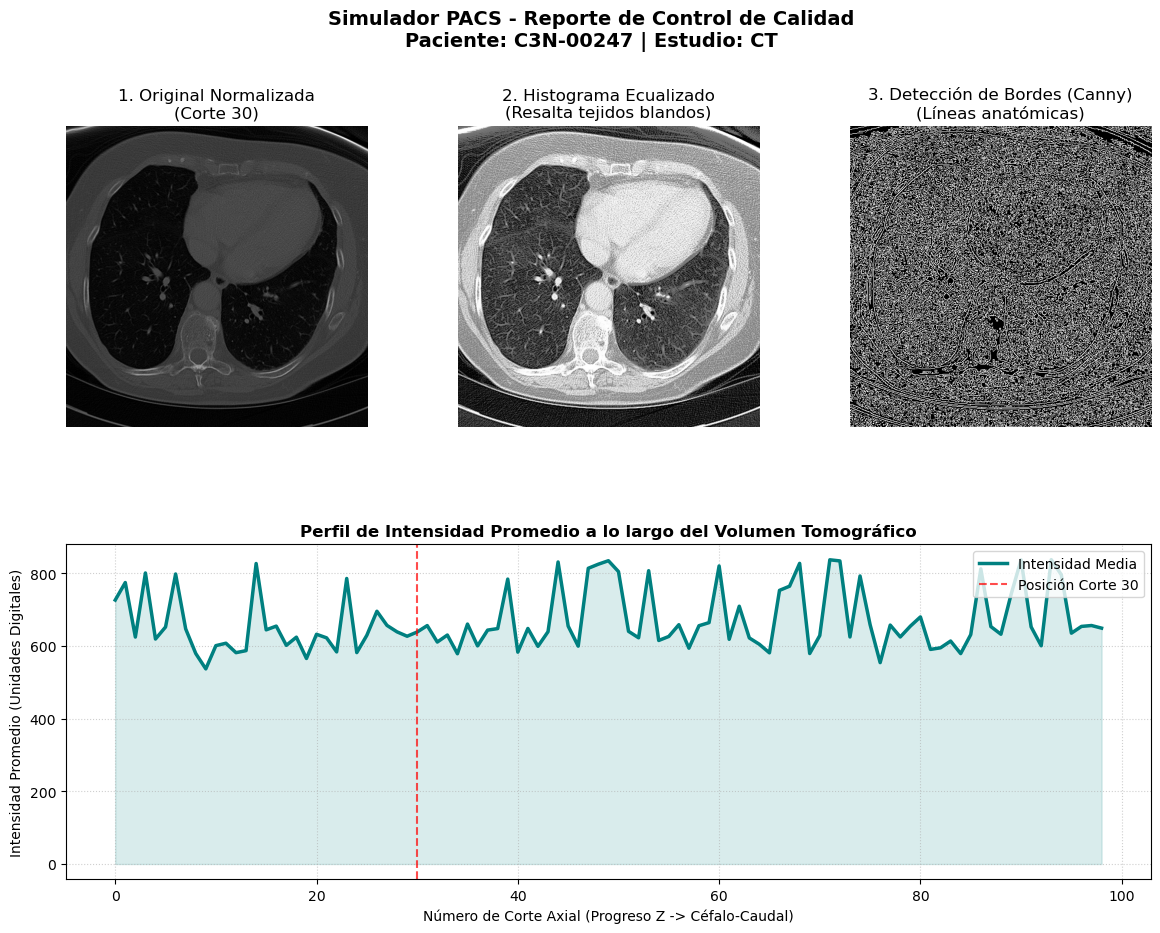

In [33]:
# ==========================================
# EJEMPLO DE USO DEL MÓDULO (Simulación)
# ==========================================
if __name__ == "__main__":
    # 1. Directorios de trabajo
    ruta_datos_dicom = 'C:/Users/Usuario/Downloads/Datos/Datos/'
    ruta_salida_imagenes = 'C:/Users/Usuario/Downloads/Datos/Resultados_OpenCV/'
    ruta_csv_salida = 'C:/Users/Usuario/Downloads/Datos/metadatos_pacs.csv'

    # 2. Inicializar el Pipeline del PACS
    pacs = ProcesadorDICOM(ruta_datos_dicom)

    # 3. Cargar y validar (4.1)
    pacs.cargar_archivos_dicom()

    # 4. Extraer metadata + Análisis Estadístico NumPy (4.2 y 4.4)
    df_clinico = pacs.extraer_metadatos()

    # 5. Guardar base de datos tabular
    pacs.exportar_a_csv(ruta_csv_salida)

    # 6. Procesar Imágenes con OpenCV (4.5)
    # Justificamos umbrales estándar para tomografía de tórax/abdomen (30, 150)
    pacs.procesar_imagenes_opencv(ruta_salida_imagenes, umbral_low=30, umbral_high=150)

    # 7. Desplegar verificación final del DataFrame en consola
    print("\n=== RESUMEN DE CONTROL DE CALIDAD DEL TALLER ===")
    print(df_clinico[['ID_Paciente', 'Modalidad', 'IntensidadPromedio', 'Nombre_Archivo_Origen']].head())

    generar_reporte_grafico(pacs, df_clinico, indice_corte=30)


    